# Explainable AI for Post-COVID Psychological Profile Prediction
## CS 198 Implementation

https: // www.kaggle.com / code / feyiamujo / depression - stress - and -anxiety - prediction
# Data Preparation

In [1]:
# -------------------------------------
# Library configuration
# -------------------------------------

# Standard libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import re


In [2]:
# Lucky number
random_state = 8

In [3]:
# Loading dataset
dataset = pd.read_csv('../../data/processed/cs199_data.csv')
dataset.head(10)

C:\Users\wakib\AppData\Local\Temp\ipykernel_11668\3782930721.py:2: DtypeWarning: Columns (1,86,87,88) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('../../data/processed/cs199_data.csv')


,SAMPLEID,6_ANSWERDATE,6_SEX,6_AGE,6_AGEID,6_PREFECTURE,6_AREA,6_MARRIED,6_CHILD,6_HINCOME,...,6_Mental_group,6_Covid_group,6_K6_group3,6_K6_group2,6_PHQ9_%,6_GAD_%,6_PHQ9_item9,6_PHQ9_SI,6_LSNS_group,6_AUDIT_group
0,1106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3793,5-13-2024,1.0,57.0,10.0,40.0,8.0,2.0,2.0,4.0,...,4.0,4.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0
5,3827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,5765,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8488,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9703,5-14-2024,2.0,70.0,11.0,28.0,5.0,2.0,2.0,7.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,10761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24050 entries, 0 to 24049
Columns: 114 entries, SAMPLEID to 6_AUDIT_group
dtypes: float64(109), int64(1), object(4)
memory usage: 20.9+ MB


In [5]:
# Check for duplicates on each row.
dataset.duplicated().value_counts()

False    24050
Name: count, dtype: int64

In [6]:
# Check for unique values.
dataset.nunique()
columns = dataset.columns
print('Attributes', columns)
for column in columns:
    print(column)

Attributes Index(['SAMPLEID', '6_ANSWERDATE', '6_SEX', '6_AGE', '6_AGEID', '6_PREFECTURE',
       '6_AREA', '6_MARRIED', '6_CHILD', '6_HINCOME',
       ...
       '6_Mental_group', '6_Covid_group', '6_K6_group3', '6_K6_group2',
       '6_PHQ9_%', '6_GAD_%', '6_PHQ9_item9', '6_PHQ9_SI', '6_LSNS_group',
       '6_AUDIT_group'],
      dtype='object', length=114)
SAMPLEID
6_ANSWERDATE
6_SEX
6_AGE
6_AGEID
6_PREFECTURE
6_AREA
6_MARRIED
6_CHILD
6_HINCOME
6_PINCOME
6_JOB
6_STUDENT
6_Number_fam
6_SchoolGrade
6_YearsEnrolled
6_VacNum
6_Med_self
6_Medself_covid
6_Med_fam
6_Medfam_covid
6_Current_physical
6_Past_physical
6_Current_mental
6_Past_mental
6_Current_covid19
6_Past_covid19
6_Exercise
6_HealthyDiet
6_FavoriteActivity
6_Interaction_offline
6_Interaction_online
6_PB_Continuous
6_PB_Altruistic
6_PB_Avoidant
6_Trust_gov
6_Trust_SM
6_Vaccination_will
6_PB_understanding
6_Optimism
6_HealthySleep
6_DeteriorationEconomy
6_DeteriorationInteract
6_Frustration
6_CovidAnxiety
6_CovidSleepless
6_Diff

In [7]:
## Data Preprocessing
# Sorting dataset based on SAMPLEID
dataset_sorted = dataset.sort_values(by=['SAMPLEID'])


In [8]:
# Displaying sorted dataset
dataset_sorted.head(10)

,SAMPLEID,6_ANSWERDATE,6_SEX,6_AGE,6_AGEID,6_PREFECTURE,6_AREA,6_MARRIED,6_CHILD,6_HINCOME,...,6_Mental_group,6_Covid_group,6_K6_group3,6_K6_group2,6_PHQ9_%,6_GAD_%,6_PHQ9_item9,6_PHQ9_SI,6_LSNS_group,6_AUDIT_group
0,1106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16161,1171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16162,1263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14191,1346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18612,1398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3793,5-13-2024,1.0,57.0,10.0,40.0,8.0,2.0,2.0,4.0,...,4.0,4.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0
5,3827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Dropping empty rows from sorted dataset
dataset_cleaned = dataset_sorted.dropna()

In [10]:
# Displaying cleaned dataset
dataset_cleaned.head(10)

,SAMPLEID,6_ANSWERDATE,6_SEX,6_AGE,6_AGEID,6_PREFECTURE,6_AREA,6_MARRIED,6_CHILD,6_HINCOME,...,6_Mental_group,6_Covid_group,6_K6_group3,6_K6_group2,6_PHQ9_%,6_GAD_%,6_PHQ9_item9,6_PHQ9_SI,6_LSNS_group,6_AUDIT_group
4,3793,5-13-2024,1.0,57.0,10.0,40.0,8.0,2.0,2.0,4.0,...,4.0,4.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0
8,9703,5-14-2024,2.0,70.0,11.0,28.0,5.0,2.0,2.0,7.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
11,11532,5-11-2024,1.0,52.0,9.0,13.0,3.0,1.0,1.0,3.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
15,15778,5-10-2024,1.0,66.0,11.0,27.0,5.0,2.0,2.0,4.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
19,18713,5-10-2024,1.0,63.0,11.0,13.0,3.0,2.0,2.0,7.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
21,19076,5-13-2024,1.0,62.0,11.0,40.0,8.0,1.0,2.0,3.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
22,20396,5-11-2024,1.0,69.0,11.0,13.0,3.0,2.0,2.0,3.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
24,22140,5-11-2024,1.0,53.0,9.0,13.0,3.0,1.0,1.0,10.0,...,4.0,4.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0
27,23362,5-11-2024,1.0,46.0,8.0,13.0,3.0,1.0,1.0,4.0,...,4.0,4.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0
31,27241,5-10-2024,1.0,55.0,10.0,13.0,3.0,1.0,1.0,4.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0


In [11]:
# Gathering columns
column_names = dataset_cleaned.columns.tolist()

In [12]:
# Displaying column names
column_names

['SAMPLEID',
 '6_ANSWERDATE',
 '6_SEX',
 '6_AGE',
 '6_AGEID',
 '6_PREFECTURE',
 '6_AREA',
 '6_MARRIED',
 '6_CHILD',
 '6_HINCOME',
 '6_PINCOME',
 '6_JOB',
 '6_STUDENT',
 '6_Number_fam',
 '6_SchoolGrade',
 '6_YearsEnrolled',
 '6_VacNum',
 '6_Med_self',
 '6_Medself_covid',
 '6_Med_fam',
 '6_Medfam_covid',
 '6_Current_physical',
 '6_Past_physical',
 '6_Current_mental',
 '6_Past_mental',
 '6_Current_covid19',
 '6_Past_covid19',
 '6_Exercise',
 '6_HealthyDiet',
 '6_FavoriteActivity',
 '6_Interaction_offline',
 '6_Interaction_online',
 '6_PB_Continuous',
 '6_PB_Altruistic',
 '6_PB_Avoidant',
 '6_Trust_gov',
 '6_Trust_SM',
 '6_Vaccination_will',
 '6_PB_understanding',
 '6_Optimism',
 '6_HealthySleep',
 '6_DeteriorationEconomy',
 '6_DeteriorationInteract',
 '6_Frustration',
 '6_CovidAnxiety',
 '6_CovidSleepless',
 '6_DifficultyLiving',
 '6_DifficultyWork',
 '6_PTG1_S22',
 '6_PTG2_S23',
 '6_PTG3_S24',
 '6_PTG4_S25',
 '6_PTG5_S_26',
 '6_PTG6_S27',
 '6_Social_Capital_Q8S1',
 '6_Social_Capital_Q8S2

In [13]:
# Setting attributes
attributes = dataset_cleaned[[
 #'SAMPLEID',
 #'6_ANSWERDATE',
 '6_SEX', #"1 Male 2 Female"
 '6_AGE',
 #'6_AGEID',
 #'6_PREFECTURE',
 #'6_AREA',
 '6_MARRIED', #"1 unmarried 2 married"
 '6_CHILD', #"1 no children 2 with children"
 '6_HINCOME',
 '6_PINCOME', #same coding as HINCOME
 '6_JOB',
 #'6_STUDENT',
 '6_Number_fam', #Please indicate by number how many people (not including yourself) live with you.
 #'6_SchoolGrade',
 #'6_YearsEnrolled',
 '6_VacNum', #Number of vaccinations

 '6_Med_self', # "I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.) 1 yes 2 no"
 '6_Medself_covid', # "As a medical worker, I am dealing with new corona patients. 1 yes 2 no"
 '6_Med_fam', #"Have a family member who is a healthcare worker 1 yes 2 no"
 '6_Medfam_covid', #"There is a person in the family who is dealing with new corona patients as a medical worker. 　1 yes 2 no"
 '6_Current_physical', #Whether the respondent has been treated for a physical illness in the past
 '6_Past_physical', #Whether the respondent is currently being treated for a mental disorder
 '6_Current_mental', #Whether the respondent has been treated for mental illness in the past
 '6_Past_mental', #Currently being treated for COVID-19
 '6_Current_covid19', #"Currently undergoing treatment for COVID-19. 1 yes 2 no"
 '6_Past_covid19', #"Have received treatment for COVID-19 in the past. 1 yes 2 no"

 '6_Exercise',
 '6_HealthyDiet',
 '6_FavoriteActivity',
 '6_Interaction_offline',
 '6_Interaction_online',

 '6_PB_Continuous', #We continued to take preventive actions against the new coronavirus infection (wearing a mask, washing hands, limiting going out, etc.).
 '6_PB_Altruistic', #Voluntarily took preventive actions (wearing a mask, washing hands, limiting going out, etc.) to prevent the spread of the new coronavirus to family members and others.
 '6_PB_Avoidant', #To avoid social criticism and pressure, they took preventive actions (wearing masks, washing hands, limiting going out, etc.).
 '6_Trust_gov',
 '6_Trust_SM',
 '6_Vaccination_will',
 '6_PB_understanding',
 '6_Optimism',
 '6_HealthySleep',
 '6_DeteriorationEconomy',
 '6_DeteriorationInteract',
 '6_Frustration',
 '6_CovidAnxiety',
 '6_CovidSleepless',
 '6_DifficultyLiving',
 '6_DifficultyWork',

 #'6_PTG1_S22',
 #'6_PTG2_S23',
 #'6_PTG3_S24',
 #'6_PTG4_S25',
 #'6_PTG5_S_26',
 #'6_PTG6_S27',
 #'6_Social_Capital_Q8S1',
 #'6_Social_Capital_Q8S2',
 #'6_Social_Capital_Q8S3',
 #'6_Social_Capital_Q8S4',
 #'6_Social_Capital_Q8S5',
 #'6_Social_Capital_Q9S1',
 #'6_Social_Capital_Q9S2',
 #'6_Social_Capital_Q9S3',
 #'6_Social_Capital_Q10S1_1',
 #'6_Social_Capital_Q10S1_2',
 #'6_Social_Capital_Q10S1_3',
 #'6_Social_Capital_Q10S1_4',
 #'6_Social_Capital_Q10S1_5',
 #'6_Social_Capital_Q10S1_6',
 #'6_Social_Capital_Q10S1_7',
 #'6_Social_Capital_Q10S1_8',
 #'6_Social_Capital_Q10S2_1',
 #'6_Social_Capital_Q10S2_2',
 #'6_Social_Capital_Q10S2_3',
 #'6_Social_Capital_Q10S2_4',
 #'6_Social_Capital_Q10S2_5',
 #'6_Social_Capital_Q10S2_6',
 #'6_Social_Capital_Q10S2_7',
 #'6_Social_Capital_Q10S2_8',
 #'6_Social_Capital_Q10S3_1',
 #'6_Social_Capital_Q10S3_2',
 #'6_Social_Capital_Q10S3_3',
 #'6_Social_Capital_Q10S3_4',
 #'6_Social_Capital_Q10S3_5',
 #'6_Social_Capital_Q10S3_6',
 #'6_Social_Capital_Q10S3_7',
 #'6_Social_Capital_Q10S3_8',
 #'6_Social_Capital_Q10S1_7FA',
 #'6_Social_Capital_Q10S2_7FA',
 #'6_Social_Capital_Q10S3_7FA',
 '6_K6_total',
 '6_PHQ9_total',
 '6_GAD7_total',
 '6_SSS8_total',
 '6_PTGI-X(Q7_22_27)',
 '6_SHS_total',
 '6_UCLA_total',
 '6_LSNS6_total',
 '6_AUDIT']]



In [14]:
num_attributes = len(attributes.columns.tolist())
num_attributes
attributes.head(10)

,6_SEX,6_AGE,6_MARRIED,6_CHILD,6_HINCOME,6_PINCOME,6_JOB,6_Number_fam,6_VacNum,6_Med_self,...,6_DifficultyWork,6_K6_total,6_PHQ9_total,6_GAD7_total,6_SSS8_total,6_PTGI-X(Q7_22_27),6_SHS_total,6_UCLA_total,6_LSNS6_total,6_AUDIT
4,1.0,57.0,2.0,2.0,4.0,3.0,4.0,2.0,3.0,2.0,...,5.0,12.0,15.0,14.0,18.0,19.0,4.00,24.0,4.0,6.0
8,2.0,70.0,2.0,2.0,7.0,1.0,8.0,3.0,3.0,2.0,...,6.0,1.0,0.0,0.0,1.0,3.0,4.50,11.0,18.0,0.0
11,1.0,52.0,1.0,1.0,3.0,3.0,3.0,1.0,3.0,2.0,...,1.0,1.0,2.0,0.0,1.0,0.0,4.00,32.0,0.0,0.0
15,1.0,66.0,2.0,2.0,4.0,2.0,3.0,3.0,3.0,2.0,...,1.0,0.0,0.0,0.0,0.0,18.0,5.50,21.0,13.0,0.0
19,1.0,63.0,2.0,2.0,7.0,7.0,2.0,1.0,5.0,2.0,...,4.0,0.0,2.0,0.0,0.0,15.0,5.25,22.0,18.0,0.0
21,1.0,62.0,1.0,2.0,3.0,3.0,4.0,1.0,5.0,2.0,...,4.0,0.0,0.0,0.0,6.0,18.0,3.75,24.0,5.0,5.0
22,1.0,69.0,2.0,2.0,3.0,2.0,9.0,1.0,6.0,2.0,...,2.0,0.0,0.0,0.0,5.0,11.0,4.25,23.0,3.0,13.0
24,1.0,53.0,1.0,1.0,10.0,3.0,7.0,1.0,2.0,2.0,...,4.0,6.0,8.0,6.0,10.0,9.0,3.25,28.0,6.0,0.0
27,1.0,46.0,1.0,1.0,4.0,2.0,11.0,2.0,3.0,2.0,...,4.0,7.0,3.0,2.0,11.0,6.0,4.25,29.0,6.0,0.0
31,1.0,55.0,1.0,1.0,4.0,4.0,3.0,0.0,5.0,2.0,...,3.0,0.0,2.0,1.0,10.0,16.0,3.50,28.0,6.0,16.0


In [15]:

# Setting targets
targets = dataset_cleaned[
    ['6_K6_total',
     '6_PHQ9_total',
     '6_GAD7_total',
     '6_SSS8_total',
     '6_PTGI-X(Q7_22_27)',
     '6_SHS_total',
     '6_UCLA_total',
     '6_LSNS6_total',
     '6_AUDIT']]

num_targets = len(targets.columns.tolist())
targets.head(10)

,6_K6_total,6_PHQ9_total,6_GAD7_total,6_SSS8_total,6_PTGI-X(Q7_22_27),6_SHS_total,6_UCLA_total,6_LSNS6_total,6_AUDIT
4,12.0,15.0,14.0,18.0,19.0,4.00,24.0,4.0,6.0
8,1.0,0.0,0.0,1.0,3.0,4.50,11.0,18.0,0.0
11,1.0,2.0,0.0,1.0,0.0,4.00,32.0,0.0,0.0
15,0.0,0.0,0.0,0.0,18.0,5.50,21.0,13.0,0.0
19,0.0,2.0,0.0,0.0,15.0,5.25,22.0,18.0,0.0
21,0.0,0.0,0.0,6.0,18.0,3.75,24.0,5.0,5.0
22,0.0,0.0,0.0,5.0,11.0,4.25,23.0,3.0,13.0
24,6.0,8.0,6.0,10.0,9.0,3.25,28.0,6.0,0.0
27,7.0,3.0,2.0,11.0,6.0,4.25,29.0,6.0,0.0
31,0.0,2.0,1.0,10.0,16.0,3.50,28.0,6.0,16.0


TARGET
Unlikely distress    2469
Likely distress       190
Name: count, dtype: int64


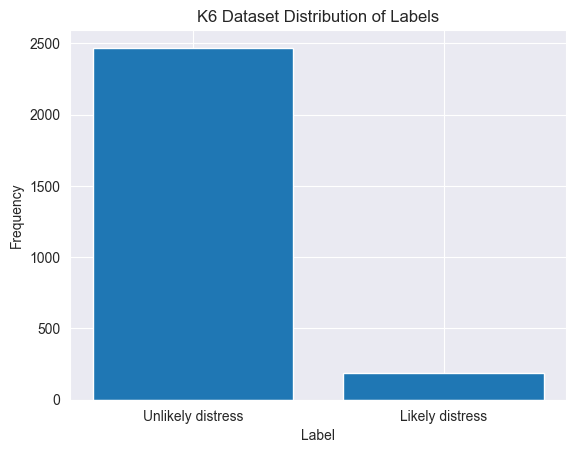

In [16]:
## K6 Dataset
# Declaring function for K6
def k6_condition(x):
    if 0 <= x <= 12:
        return 'Unlikely distress'
    elif 13 <= x <= 24:
        return 'Likely distress'


target_name = '6_K6_total'

target_column = targets[[target_name]].rename(columns={target_name: 'TARGET'})
attributes.columns = attributes.columns.str.lower().str.replace('^5_', '', regex=True)
k6_dataset = pd.concat([attributes, target_column], axis=1)
k6_dataset.head(10)
# Count the frequency of each label
k6_dataset['TARGET'] = k6_dataset['TARGET'].apply(k6_condition)

label_counts = k6_dataset['TARGET'].value_counts()

print(label_counts)
# Plot the bar chart
plt.bar(label_counts.index, label_counts.values)

# Add labels and title
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('K6 Dataset Distribution of Labels')

# Show the plot
plt.show()

TARGET
Minimal depression    2001
Mild                   353
Moderate               142
Moderately severe       92
Severe                  71
Name: count, dtype: int64


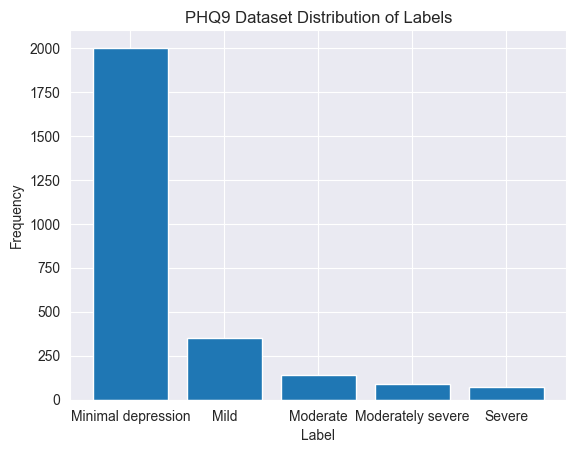

In [17]:
## PHQ9 Dataset
# Declaring function for PHQ-9
def phq9_condition(x):
    if 0 <= x <= 4:
        return 'Minimal depression'
    elif 5 <= x <= 9:
        return 'Mild'
    elif 10 <= x <= 14:
        return 'Moderate'
    elif 15 <= x <= 19:
        return 'Moderately severe'
    elif 20 <= x <= 27:
        return 'Severe'


target_name = '6_PHQ9_total'

target_column = targets[[target_name]].rename(columns={target_name: 'TARGET'})
attributes.columns = attributes.columns.str.lower().str.replace('^5_', '', regex=True)
phq9_dataset = pd.concat([attributes, target_column], axis=1)
phq9_dataset.head(10)
# Count the frequency of each label
phq9_dataset['TARGET'] = phq9_dataset['TARGET'].apply(phq9_condition)

label_counts = phq9_dataset['TARGET'].value_counts()

print(label_counts)
# Plot the bar chart
plt.bar(label_counts.index, label_counts.values)

# Add labels and title
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('PHQ9 Dataset Distribution of Labels')

# Show the plot
plt.show()


TARGET
Minimal anxiety    2161
Mild                316
Moderate            102
Severe               80
Name: count, dtype: int64


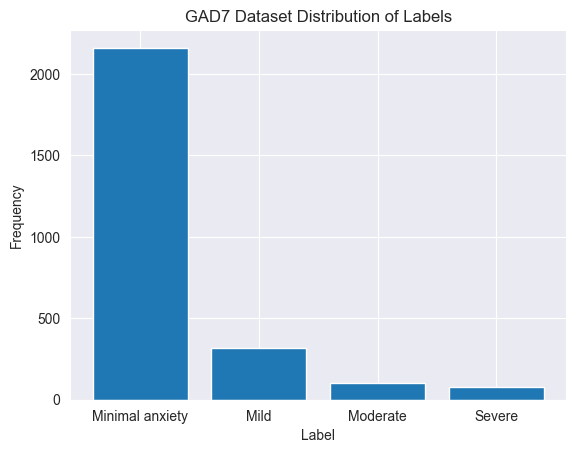

In [18]:
## GAD7 Dataset
# Declaring function for GAD-7
def gad7_condition(x):
    if 0 <= x <= 4:
        return 'Minimal anxiety'
    elif 5 <= x <= 9:
        return 'Mild'
    elif 10 <= x <= 14:
        return 'Moderate'
    elif 15 <= x <= 21:
        return 'Severe'


target_name = '6_GAD7_total'

target_column = targets[[target_name]].rename(columns={target_name: 'TARGET'})
attributes.columns = attributes.columns.str.lower().str.replace('^5_', '', regex=True)
gad7_dataset = pd.concat([attributes, target_column], axis=1)
gad7_dataset.head(10)
# Count the frequency of each label
gad7_dataset['TARGET'] = gad7_dataset['TARGET'].apply(gad7_condition)

label_counts = gad7_dataset['TARGET'].value_counts()

print(label_counts)
# Plot the bar chart
plt.bar(label_counts.index, label_counts.values)

# Add labels and title
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('GAD7 Dataset Distribution of Labels')

# Show the plot
plt.show()


TARGET
Minimal      1471
Low           567
Medium        301
High          168
Very high     152
Name: count, dtype: int64


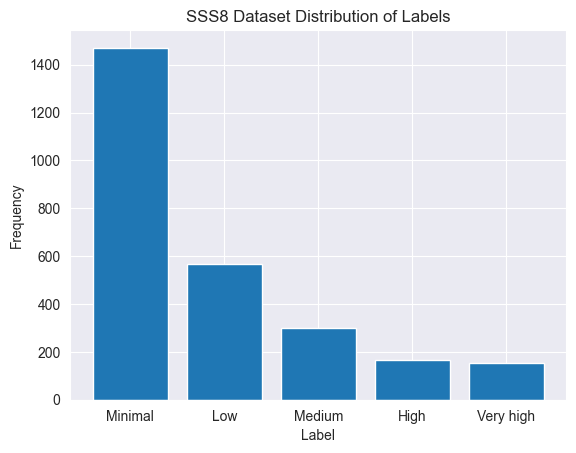

In [19]:
## SSS8 Dataset
# Declaring function for SSS-8
def sss8_condition(x):
    if 0 <= x <= 3:
        return 'Minimal'
    elif 4 <= x <= 7:
        return 'Low'
    elif 8 <= x <= 11:
        return 'Medium'
    elif 12 <= x <= 15:
        return 'High'
    elif 16 <= x <= 32:
        return 'Very high'


target_name = '6_SSS8_total'

match = re.search(r'6_([A-Za-z0-9]+)_', target_name)
if match:
    middle_text = match.group(1)
else:
    middle_text = 'NONE'

target_column = targets[[target_name]].rename(columns={target_name: 'TARGET'})
attributes.columns = attributes.columns.str.lower().str.replace('^5_', '', regex=True)
sss8_dataset = pd.concat([attributes, target_column], axis=1)
sss8_dataset.head(10)
# Count the frequency of each label
sss8_dataset['TARGET'] = sss8_dataset['TARGET'].apply(sss8_condition)

label_counts = sss8_dataset['TARGET'].value_counts()

print(label_counts)
# Plot the bar chart
plt.bar(label_counts.index, label_counts.values)

# Add labels and title
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('SSS8 Dataset Distribution of Labels')

# Show the plot
plt.show()


TARGET
Intermediate happiness    2583
High happiness              49
Low happiness               27
Name: count, dtype: int64


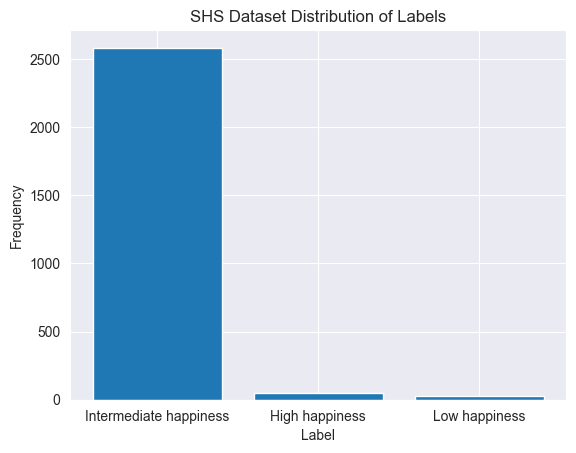

In [20]:
## SHS Dataset
# Declaring function for SHS (Subjective Happiness Scale)
def shs_condition(x):
    if x == 1:
        return 'Low happiness'
    elif x == 7:
        return 'High happiness'
    else:
        return 'Intermediate happiness'


target_name = '6_SHS_total'

target_column = targets[[target_name]].rename(columns={target_name: 'TARGET'})
attributes.columns = attributes.columns.str.lower().str.replace('^5_', '', regex=True)
shs_dataset = pd.concat([attributes, target_column], axis=1)
shs_dataset.head(10)
# Count the frequency of each label
shs_dataset['TARGET'] = shs_dataset['TARGET'].apply(shs_condition)

label_counts = shs_dataset['TARGET'].value_counts()

print(label_counts)
# Plot the bar chart
plt.bar(label_counts.index, label_counts.values)

# Add labels and title
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('SHS Dataset Distribution of Labels')

# Show the plot
plt.show()


TARGET
25.0    363
26.0    217
24.0    208
23.0    173
21.0    146
22.0    134
20.0    134
27.0    110
28.0    106
19.0    105
17.0     85
16.0     82
29.0     79
18.0     75
30.0     66
14.0     64
15.0     64
31.0     62
12.0     51
13.0     49
11.0     42
32.0     41
33.0     34
34.0     34
40.0     23
35.0     22
37.0     21
36.0     20
39.0     19
10.0     16
38.0     14
Name: count, dtype: int64


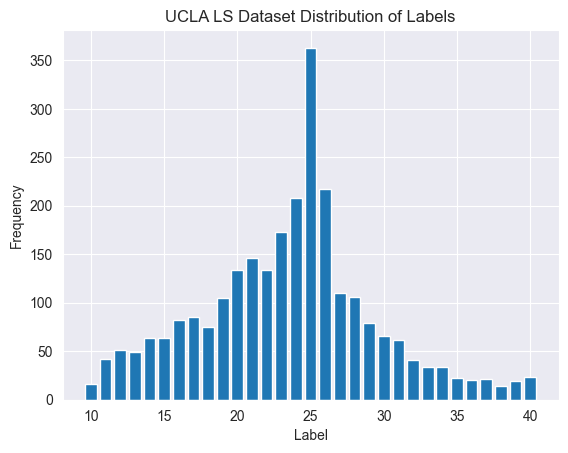

In [21]:
## UCLA Dataset
# Declaring function for UCLA Loneliness Scale (UCLA LS)
def ucla_ls_condition(x):
    return x


target_name = '6_UCLA_total'

target_column = targets[[target_name]].rename(columns={target_name: 'TARGET'})
attributes.columns = attributes.columns.str.lower().str.replace('^5_', '', regex=True)
ucla_dataset = pd.concat([attributes, target_column], axis=1)
ucla_dataset.head(10)
# Count the frequency of each label
ucla_dataset['TARGET'] = ucla_dataset['TARGET'].apply(ucla_ls_condition)

label_counts = ucla_dataset['TARGET'].value_counts()

print(label_counts)
# Plot the bar chart
plt.bar(label_counts.index, label_counts.values)

# Add labels and title
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('UCLA LS Dataset Distribution of Labels')

# Show the plot
plt.show()


TARGET
Intermediate social engagement    2374
Minimal social engagement          285
Name: count, dtype: int64


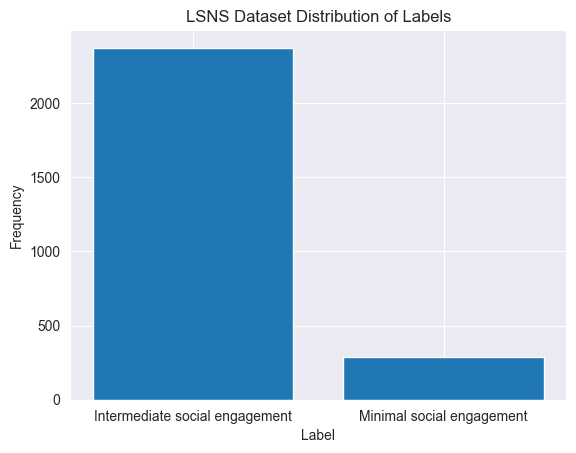

In [22]:
## LSNS6 Dataset
# Declaring function for LSNS-6
def lsns6_condition(x):
    if x == 0:
        return 'Minimal social engagement'
    elif x == 60:
        return 'High social engagement'
    else:
        return 'Intermediate social engagement'


target_name = '6_LSNS6_total'

target_column = targets[[target_name]].rename(columns={target_name: 'TARGET'})
attributes.columns = attributes.columns.str.lower().str.replace('^5_', '', regex=True)
lsns6_dataset = pd.concat([attributes, target_column], axis=1)
lsns6_dataset.head(10)
# Count the frequency of each label
lsns6_dataset['TARGET'] = lsns6_dataset['TARGET'].apply(lsns6_condition)

label_counts = lsns6_dataset['TARGET'].value_counts()

print(label_counts)
# Plot the bar chart
plt.bar(label_counts.index, label_counts.values)

# Add labels and title
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('LSNS Dataset Distribution of Labels')

# Show the plot
plt.show()


## PTGI-X Dataset
Will
do
this
soon
target_name = '6_PTGI-X(Q7_22_27)'
middle_text = 'PTGI-X'

target_column = targets[[target_name]].rename(columns={target_name: 'TARGET'})
attributes.columns = attributes.columns.str.lower().str.replace('^5_', '', regex=True)
ptgix_dataset = pd.concat([attributes, target_column], axis=1)
ptgix_dataset.head(10)

## AUDIT Dataset
Will
do
this
soon
target_name = '6_AUDIT'
middle_text = 'AUDIT'

target_column = targets[[target_name]].rename(columns={target_name: 'TARGET'})
attributes.columns = attributes.columns.str.lower().str.replace('^5_', '', regex=True)
audit_dataset = pd.concat([attributes, target_column], axis=1)
audit_dataset.head(10)


In [23]:
# Splitting datasets
# -------------------------------------
# Library configuration
# -------------------------------------

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, \
    f1_score

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier


In [24]:
## K6 Dataset
# Extract the target and features
k6_y = k6_dataset['TARGET']
k6_X = k6_dataset.drop(columns=['TARGET'])

# K6 labels
k6_labels = [
    "Unlikely distress",
    "Likely distress"
]

# Encode the labels
encoder = LabelEncoder()
encoded_k6_label = encoder.fit_transform(k6_labels)

# Reflect encoder changes in k6_y
k6_y_encoded = encoder.transform(k6_y)

#Get the training and test set from the K6 dataset
k6_X_train, k6_X_test, k6_y_train, k6_y_test = train_test_split(k6_X, k6_y_encoded, test_size=0.3, random_state=30)

# Calculate the count of each unique label
unique_labels, label_counts = np.unique(k6_y_test, return_counts=True)

print("Test data distribution")
# Print the label counts
for label, count in zip(unique_labels, label_counts):
    print(f"Label: {label}, Count: {count}")


Test data distribution
Label: 0, Count: 61
Label: 1, Count: 737


In [25]:
## PHQ9 Dataset
# Extract the target and features
phq9_y = phq9_dataset['TARGET']
phq9_X = phq9_dataset.drop(columns=['TARGET'])

# PHQ-9 labels
phq9_labels = [
    "Minimal depression",
    "Mild",
    "Moderate",
    "Moderately severe",
    "Severe"
]

# Encode the labels
encoder = LabelEncoder()
encoded_phq9_label = encoder.fit_transform(phq9_labels)

# Reflect encoder changes in k6_y
phq9_y_encoded = encoder.transform(phq9_y)

#Get the training and test set from the K6 dataset
phq9_X_train, phq9_X_test, phq9_y_train, phq9_y_test = train_test_split(phq9_X, phq9_y_encoded, test_size=0.3,
                                                                        random_state=30)

# Calculate the count of each unique label
unique_labels, label_counts = np.unique(phq9_y_test, return_counts=True)

print("Test data distribution")
# Print the label counts
for label, count in zip(unique_labels, label_counts):
    print(f"Label: {label}, Count: {count}")


Test data distribution
Label: 0, Count: 104
Label: 1, Count: 596
Label: 2, Count: 51
Label: 3, Count: 25
Label: 4, Count: 22


In [26]:
## GAD7 Dataset
# Extract the target and features
gad7_y = gad7_dataset['TARGET']
gad7_X = gad7_dataset.drop(columns=['TARGET'])

# GAD-7 labels
gad7_labels = [
    "Minimal anxiety",
    "Mild",
    "Moderate",
    "Severe"
]

# Encode the labels
encoder = LabelEncoder()
encoded_gad7_label = encoder.fit_transform(gad7_labels)

# Reflect encoder changes in k6_y
gad7_y_encoded = encoder.transform(gad7_y)

#Get the training and test set from the K6 dataset
gad7_X_train, gad7_X_test, gad7_y_train, gad7_y_test = train_test_split(gad7_X, gad7_y_encoded, test_size=0.3,
                                                                        random_state=30)

# Calculate the count of each unique label
unique_labels, label_counts = np.unique(gad7_y_test, return_counts=True)

print("Test data distribution")
# Print the label counts
for label, count in zip(unique_labels, label_counts):
    print(f"Label: {label}, Count: {count}")


Test data distribution
Label: 0, Count: 99
Label: 1, Count: 641
Label: 2, Count: 30
Label: 3, Count: 28


In [27]:
## SSS8 Dataset
# Extract the target and features
sss8_y = sss8_dataset['TARGET']
sss8_X = sss8_dataset.drop(columns=['TARGET'])

# SSS-8 labels
sss8_labels = [
    "Minimal",
    "Low",
    "Medium",
    "High",
    "Very high"
]

# Encode the labels
encoder = LabelEncoder()
encoded_sss8_label = encoder.fit_transform(sss8_labels)

# Reflect encoder changes in k6_y
sss8_y_encoded = encoder.transform(sss8_y)

#Get the training and test set from the K6 dataset
sss8_X_train, sss8_X_test, sss8_y_train, sss8_y_test = train_test_split(sss8_X, sss8_y_encoded, test_size=0.3,
                                                                        random_state=30)

# Calculate the count of each unique label
unique_labels, label_counts = np.unique(sss8_y_test, return_counts=True)

print("Test data distribution")
# Print the label counts
for label, count in zip(unique_labels, label_counts):
    print(f"Label: {label}, Count: {count}")


Test data distribution
Label: 0, Count: 46
Label: 1, Count: 190
Label: 2, Count: 95
Label: 3, Count: 422
Label: 4, Count: 45


In [28]:
## SHS Dataset
# Extract the target and features
shs_y = shs_dataset['TARGET']
shs_X = shs_dataset.drop(columns=['TARGET'])

# SHS (Subjective Happiness Scale) labels
shs_labels = [
    "Low happiness",
    "High happiness",
    'Intermediate happiness'
]

# Encode the labels
encoder = LabelEncoder()
encoded_shs_label = encoder.fit_transform(shs_labels)

# Reflect encoder changes in k6_y
shs_y_encoded = encoder.transform(shs_y)

#Get the training and test set from the K6 dataset
shs_X_train, shs_X_test, shs_y_train, shs_y_test = train_test_split(shs_X, shs_y_encoded, test_size=0.3,
                                                                    random_state=30)

# Calculate the count of each unique label
unique_labels, label_counts = np.unique(shs_y_test, return_counts=True)

print("Test data distribution")
# Print the label counts
for label, count in zip(unique_labels, label_counts):
    print(f"Label: {label}, Count: {count}")


Test data distribution
Label: 0, Count: 20
Label: 1, Count: 769
Label: 2, Count: 9


In [29]:
## UCLA Dataset
# Extract the target and features
ucla_y = ucla_dataset['TARGET']
ucla_X = ucla_dataset.drop(columns=['TARGET'])

#Get the training and test set from the K6 dataset
ucla_X_train, ucla_X_test, ucla_y_train, ucla_y_test = train_test_split(ucla_X, ucla_y, test_size=0.3,
                                                                        random_state=30)

# Calculate the count of each unique label
unique_labels, label_counts = np.unique(ucla_y_test, return_counts=True)

print("Test data distribution")
# Print the label counts
for label, count in zip(unique_labels, label_counts):
    print(f"Label: {label}, Count: {count}")


Test data distribution
Label: 10.0, Count: 6
Label: 11.0, Count: 9
Label: 12.0, Count: 18
Label: 13.0, Count: 15
Label: 14.0, Count: 20
Label: 15.0, Count: 14
Label: 16.0, Count: 22
Label: 17.0, Count: 24
Label: 18.0, Count: 18
Label: 19.0, Count: 35
Label: 20.0, Count: 39
Label: 21.0, Count: 38
Label: 22.0, Count: 36
Label: 23.0, Count: 48
Label: 24.0, Count: 70
Label: 25.0, Count: 99
Label: 26.0, Count: 74
Label: 27.0, Count: 28
Label: 28.0, Count: 33
Label: 29.0, Count: 32
Label: 30.0, Count: 24
Label: 31.0, Count: 26
Label: 32.0, Count: 10
Label: 33.0, Count: 8
Label: 34.0, Count: 7
Label: 35.0, Count: 8
Label: 36.0, Count: 8
Label: 37.0, Count: 8
Label: 38.0, Count: 7
Label: 39.0, Count: 3
Label: 40.0, Count: 11


In [30]:
## LSNS6 Dataset
# Extract the target and features
lsns6_y = lsns6_dataset['TARGET']
lsns6_X = lsns6_dataset.drop(columns=['TARGET'])

# LSNS-6 labels
lsns6_labels = [
    "Minimal social engagement",
    "High social engagement",
    'Intermediate social engagement'
]

# Encode the labels
encoder = LabelEncoder()
encoded_shs_label = encoder.fit_transform(lsns6_labels)

# Reflect encoder changes in k6_y
lsns6_y_encoded = encoder.transform(lsns6_y)

#Get the training and test set from the K6 dataset
lsns6_X_train, lsns6_X_test, lsns6_y_train, lsns6_y_test = train_test_split(lsns6_X, lsns6_y_encoded, test_size=0.3,
                                                                            random_state=30)

# Calculate the count of each unique label
unique_labels, label_counts = np.unique(lsns6_y_test, return_counts=True)

print("Test data distribution")
# Print the label counts
for label, count in zip(unique_labels, label_counts):
    print(f"Label: {label}, Count: {count}")


Test data distribution
Label: 1, Count: 703
Label: 2, Count: 95


## PTGI-X Dataset
soon

## AUDIT Dataset
soon


In [31]:
# Model Training
# Define a function to train and predict using a given model
def train_and_predict(model, X_train, y_train, X_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return predictions


# Define a function to evaluate the model's predictions
def evaluate_model(y_test, predictions):
    accuracy = accuracy_score(y_test, predictions) * 100
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100
    f1 = f1_score(y_test, predictions, average='macro') * 100
    return accuracy, precision, recall, f1


# Define a function to print evaluation metrics
def print_evaluation_metrics(accuracy, precision, recall, f1):
    print(f"Accuracy: {accuracy:.10f}")
    print(f"Precision: {precision:.10f}")
    print(f"Recall: {recall:.10f}")
    print(f"F1-score: {f1:.10f}")


# List of models to test
models = [
    ("Random Forest", RandomForestClassifier(random_state=random_state)),
    ("K-Nearest Neighbors", KNeighborsClassifier()),
    ("Decision Tree", DecisionTreeClassifier(random_state=random_state)),
    ("Gaussian Naive Bayes", GaussianNB()),
    ("Support Vector Machine", SVC(random_state=random_state)),
    ("MLP Classifier", MLPClassifier(random_state=random_state))
]

# List of dataset names
dataset_names = ["k6", "gad7", "phq9", "sss8", "shs", "ucla", "lsns6"]


In [32]:
# Loop through each dataset and evaluate each model
for dataset_name in dataset_names:
    print(f"\nEvaluating models for dataset: {dataset_name}")

    # Retrieve the appropriate train/test data for the current dataset
    X_train = globals()[f"{dataset_name}_X_train"]
    y_train = globals()[f"{dataset_name}_y_train"]
    X_test = globals()[f"{dataset_name}_X_test"]
    y_test = globals()[f"{dataset_name}_y_test"]

    for model_name, model in models:
        print(f"\n  Model: {model_name}")
        predictions = train_and_predict(model, X_train, y_train, X_test)
        accuracy, precision, recall, f1 = evaluate_model(y_test, predictions)
        print_evaluation_metrics(accuracy, precision, recall, f1)




Evaluating models for dataset: k6

  Model: Random Forest
Accuracy: 100.0000000000
Precision: 100.0000000000
Recall: 100.0000000000
F1-score: 100.0000000000

  Model: K-Nearest Neighbors
Accuracy: 96.3659147870
Precision: 93.3509234828
Recall: 79.2368263007
F1-score: 84.6736646909

  Model: Decision Tree
Accuracy: 100.0000000000
Precision: 100.0000000000
Recall: 100.0000000000
F1-score: 100.0000000000

  Model: Gaussian Naive Bayes
Accuracy: 92.8571428571
Precision: 75.6741982507
Recall: 93.8774829281
F1-score: 81.5232005979

  Model: Support Vector Machine
Accuracy: 97.8696741855
Precision: 97.8492136910
Recall: 86.8174032965
F1-score: 91.4852218449

  Model: MLP Classifier


E:\GitHub\CS198\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 97.8696741855
Precision: 93.9016172507
Recall: 90.5765509264
F1-score: 92.1603300914

Evaluating models for dataset: gad7

  Model: Random Forest
Accuracy: 98.7468671679
Precision: 93.5346207191
Recall: 91.4285714286
F1-score: 92.4168278897

  Model: K-Nearest Neighbors
Accuracy: 88.4711779449
Precision: 67.8824336759
Recall: 57.5282522123
F1-score: 61.2262655181

  Model: Decision Tree
Accuracy: 100.0000000000
Precision: 100.0000000000
Recall: 100.0000000000
F1-score: 100.0000000000

  Model: Gaussian Naive Bayes
Accuracy: 87.8446115288
Precision: 67.0852587368
Recall: 75.8119809641
F1-score: 68.9211535322

  Model: Support Vector Machine
Accuracy: 92.8571428571
Precision: 79.7498097412
Recall: 71.0022416048
F1-score: 74.1985513406

  Model: MLP Classifier


E:\GitHub\CS198\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 97.3684210526
Precision: 88.7404720671
Recall: 87.5241297531
F1-score: 87.8815657103

Evaluating models for dataset: phq9

  Model: Random Forest
Accuracy: 97.6190476190
Precision: 90.8359047306
Recall: 86.9197860963
F1-score: 88.5561670962

  Model: K-Nearest Neighbors
Accuracy: 84.3358395990
Precision: 65.9656845405
Recall: 55.5540677509
F1-score: 59.5774390592

  Model: Decision Tree
Accuracy: 100.0000000000
Precision: 100.0000000000
Recall: 100.0000000000
F1-score: 100.0000000000

  Model: Gaussian Naive Bayes
Accuracy: 87.5939849624
Precision: 64.7729301143
Recall: 70.1919831189
F1-score: 64.8217346516

  Model: Support Vector Machine
Accuracy: 89.8496240602
Precision: 77.8341225170
Recall: 70.0526409898
F1-score: 71.9408012996

  Model: MLP Classifier


...

Accuracy: 62.1553884712
Precision: 47.6271305017
Recall: 42.2062142234
F1-score: 42.4527951962

  Model: K-Nearest Neighbors
Accuracy: 17.4185463659
Precision: 12.5068069644
Recall: 11.7947015294
F1-score: 11.4124273162

  Model: Decision Tree
Accuracy: 100.0000000000
Precision: 100.0000000000
Recall: 100.0000000000
F1-score: 100.0000000000

  Model: Gaussian Naive Bayes
Accuracy: 99.7493734336
Precision: 99.6766108820
Recall: 99.6774193548
F1-score: 99.6679127045

  Model: Support Vector Machine


E:\GitHub\CS198\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 16.0401002506
Precision: 2.6339087814
Recall: 6.1305229387
F1-score: 3.1422463480

  Model: MLP Classifier


E:\GitHub\CS198\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 28.1954887218
Precision: 23.5418592176
Recall: 24.6806814283
F1-score: 23.0233789077

Evaluating models for dataset: lsns6

  Model: Random Forest
Accuracy: 99.8746867168
Precision: 99.9289772727
Recall: 99.4736842105
F1-score: 99.6999131327

  Model: K-Nearest Neighbors
Accuracy: 91.3533834586
Precision: 84.1898395722
Recall: 69.1465149360
F1-score: 73.8292259797

  Model: Decision Tree
Accuracy: 100.0000000000
Precision: 100.0000000000
Recall: 100.0000000000
F1-score: 100.0000000000

  Model: Gaussian Naive Bayes
Accuracy: 99.1228070175
Precision: 99.5070422535
Recall: 96.3157894737
F1-score: 97.8397317648

  Model: Support Vector Machine
Accuracy: 88.9724310777
Precision: 88.9311364597
Recall: 54.1394025605
F1-score: 54.7432460301

  Model: MLP Classifier
Accuracy: 99.7493734336
Precision: 98.9690721649
Recall: 99.8577524893
F1-score: 99.4079415954


In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB  # Naive Bayes is not typically used for regression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define a function to train and predict using a given model
def train_and_predict(model, X_train, y_train, X_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return predictions

# Define a function to evaluate the model's predictions
def evaluate_model(y_test, predictions):
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return mse, mae, r2

# Define a function to print evaluation metrics
def print_evaluation_metrics(mse, mae, r2):
    print(f"Mean Squared Error (MSE): {mse:.10f}")
    print(f"Mean Absolute Error (MAE): {mae:.10f}")
    print(f"R-squared (R2): {r2:.10f}")

# List of regression models to test
models = [
    ("Random Forest", RandomForestRegressor(random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor()),
    ("Decision Tree", DecisionTreeRegressor(random_state=42)),
    ("Support Vector Regressor", SVR()),
    ("MLP Regressor", MLPRegressor(random_state=42))
]

# UCLA dataset only
print("\nEvaluating regression models for UCLA dataset")
X_train = ucla_X_train
y_train = ucla_y_train
X_test = ucla_X_test
y_test = ucla_y_test

for model_name, model in models:
    print(f"\n  Model: {model_name}")
    predictions = train_and_predict(model, X_train, y_train, X_test)
    mse, mae, r2 = evaluate_model(y_test, predictions)
    print_evaluation_metrics(mse, mae, r2)



Evaluating regression models for UCLA dataset

  Model: Random Forest
Mean Squared Error (MSE): 0.0000130326
Mean Absolute Error (MAE): 0.0004761905
R-squared (R2): 0.9999996523

  Model: K-Nearest Neighbors
Mean Squared Error (MSE): 5.4548872180
Mean Absolute Error (MAE): 1.7551378446
R-squared (R2): 0.8544727371

  Model: Decision Tree
Mean Squared Error (MSE): 0.0000000000
Mean Absolute Error (MAE): 0.0000000000
R-squared (R2): 1.0000000000

  Model: Support Vector Regressor
Mean Squared Error (MSE): 0.2422584556
Mean Absolute Error (MAE): 0.2645931544
R-squared (R2): 0.9935369498

  Model: MLP Regressor
Mean Squared Error (MSE): 0.0356191013
Mean Absolute Error (MAE): 0.1278498556
R-squared (R2): 0.9990497420


E:\GitHub\CS198\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [34]:
dataset_cleaned

,SAMPLEID,6_ANSWERDATE,6_SEX,6_AGE,6_AGEID,6_PREFECTURE,6_AREA,6_MARRIED,6_CHILD,6_HINCOME,...,6_Mental_group,6_Covid_group,6_K6_group3,6_K6_group2,6_PHQ9_%,6_GAD_%,6_PHQ9_item9,6_PHQ9_SI,6_LSNS_group,6_AUDIT_group
4,3793,5-13-2024,1.0,57.0,10.0,40.0,8.0,2.0,2.0,4.0,...,4.0,4.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0
8,9703,5-14-2024,2.0,70.0,11.0,28.0,5.0,2.0,2.0,7.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
11,11532,5-11-2024,1.0,52.0,9.0,13.0,3.0,1.0,1.0,3.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
15,15778,5-10-2024,1.0,66.0,11.0,27.0,5.0,2.0,2.0,4.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
19,18713,5-10-2024,1.0,63.0,11.0,13.0,3.0,2.0,2.0,7.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11204,26475923,5-11-2024,1.0,57.0,10.0,27.0,5.0,2.0,2.0,2.0,...,4.0,4.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0
11208,26476814,5-10-2024,1.0,55.0,10.0,13.0,3.0,2.0,2.0,7.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
11209,26476898,5-13-2024,2.0,50.0,9.0,40.0,8.0,2.0,1.0,5.0,...,4.0,3.0,3.0,2.0,0.0,0.0,1.0,1.0,1.0,0.0
11288,26520090,5-10-2024,2.0,33.0,5.0,13.0,3.0,1.0,1.0,4.0,...,3.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
